# 01 · Data Cleaning & Data Modelling

**Goal:** turn nine raw CSV files into one trustworthy, analysis-ready table with **one row per order**.

| Step | What happens |
|---|---|
| 1 | Load the 9 tables and inspect their size |
| 2 | Validate primary keys and foreign keys (is the relational model intact?) |
| 3 | Profile missing values and explain *why* they are missing |
| 4 | Sanity-check the delivery timeline (events in an impossible order) |
| 5 | Build the master table and engineer delivery features |
| 6 | Save it for notebooks 02-05 |

Source: [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (CC BY-NC-SA 4.0).

In [1]:
import sys
import warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make the project package importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import olist_analysis as oa

oa.set_style()
warnings.filterwarnings("ignore", category=DeprecationWarning)   # library-version noise, not relevant to results
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

## 1 · Load the raw tables

In [2]:
raw = oa.load_raw()

overview = pd.DataFrame({
    name: {"rows": len(df), "columns": df.shape[1], "memory_MB": df.memory_usage(deep=True).sum() / 1e6}
    for name, df in raw.items()
}).T.astype({"rows": int, "columns": int}).sort_values("rows", ascending=False)
overview.style.format({"rows": "{:,}", "memory_MB": "{:.1f}"})

,rows,columns,memory_MB
geolocation,"1,000,163",5,52.6
items,"112,650",7,17.1
payments,"103,886",5,8.5
orders,"99,441",8,13.6
customers,"99,441",5,11.6
reviews,"99,224",7,14.9
products,"32,951",9,3.9
sellers,"3,095",4,0.2
category_translation,71,2,0.0


### Relational model

```
customers 1──* orders 1──* order_items *──1 products *──1 category_translation
                  │  │            └──────*──1 sellers
                  │  └──* payments
                  └─────* reviews
geolocation: zip prefix -> lat/lng (joins to customers and sellers by postcode prefix)
```

## 2 · Key validation
A violation count of **0** on every row means the tables can be joined without losing or duplicating orders.

In [3]:
checks = oa.key_checks(raw)
checks

,check,violations
0,PK orders(order_id),0
1,PK customers(customer_id),0
2,"PK items(order_id, order_item_id)",0
3,"PK payments(order_id, payment_sequential)",0
4,PK products(product_id),0
5,PK sellers(seller_id),0
6,"PK reviews(review_id, order_id)",0
7,FK orders.customer_id -> customers.customer_id,0
8,FK items.order_id -> orders.order_id,0
9,FK items.product_id -> products.product_id,0


In [4]:
assert checks["violations"].eq(0).all(), "Key violations found - investigate before modelling"
print("All primary and foreign keys are valid.")

All primary and foreign keys are valid.


## 3 · Missing values

In [5]:
missing = (
    pd.concat({name: df.isna().mean() for name, df in raw.items() if name != "geolocation"})
    .rename("missing_share").reset_index()
    .rename(columns={"level_0": "table", "level_1": "column"})
    .query("missing_share > 0")
    .sort_values("missing_share", ascending=False)
)
missing.style.format({"missing_share": "{:.2%}"}).hide(axis="index")

table,column,missing_share
reviews,review_comment_title,88.34%
reviews,review_comment_message,58.70%
orders,order_delivered_customer_date,2.98%
products,product_name_lenght,1.85%
products,product_category_name,1.85%
products,product_description_lenght,1.85%
products,product_photos_qty,1.85%
orders,order_delivered_carrier_date,1.79%
orders,order_approved_at,0.16%
products,product_weight_g,0.01%


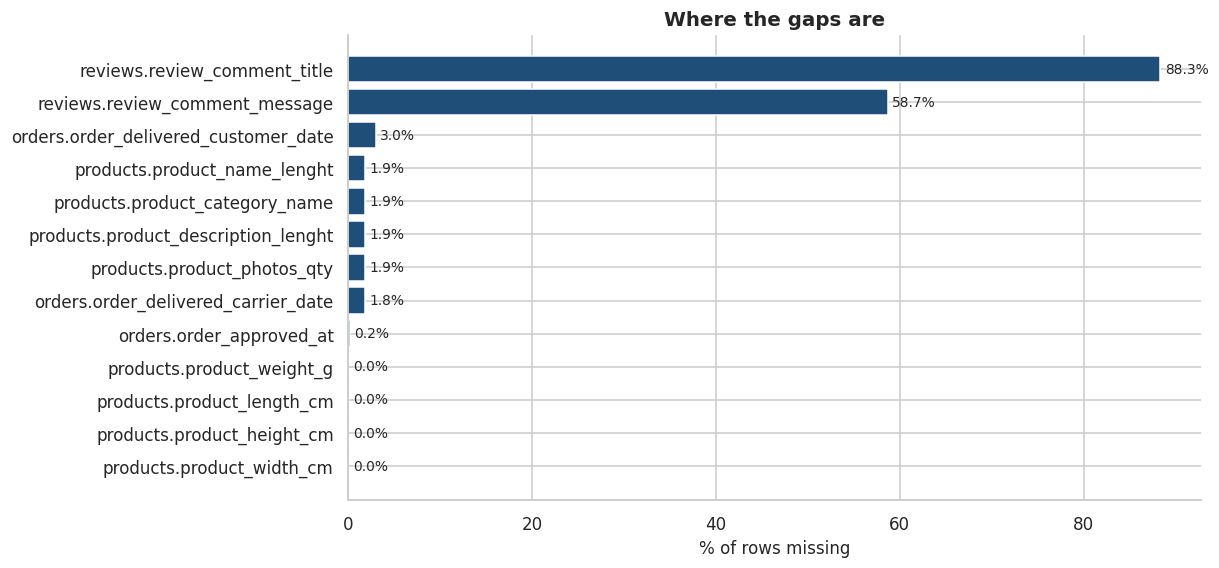

In [6]:
fig, ax = plt.subplots(figsize=(10, 5.5))
labels = missing["table"] + "." + missing["column"]
ax.barh(labels, missing["missing_share"] * 100, color=oa.BASE)
ax.invert_yaxis()
ax.set_xlabel("% of rows missing")
ax.set_title("Where the gaps are")
for y, v in enumerate(missing["missing_share"] * 100):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center", fontsize=9)
oa.save(fig, "01_missing_values")
plt.show()

**Interpretation**

* **Review title / message** - mostly empty because writing a comment is optional. Not an error; the score itself is almost always present.
* **Delivery and carrier dates** - missing for orders that were never delivered (cancelled, unavailable, still in transit). Check below.
* **Product attributes** - ~1.9 % of products have no category or dimensions. They are kept and labelled `unknown`.

In [7]:
o = raw["orders"]
pd.crosstab(o["order_status"], o["order_delivered_customer_date"].isna(), margins=True) \
  .rename(columns={False: "has delivery date", True: "no delivery date"})

order_delivered_customer_date,has delivery date,no delivery date,All
order_status,,,
approved,0,2,2
canceled,6,619,625
created,0,5,5
delivered,96470,8,96478
invoiced,0,314,314
processing,0,301,301
shipped,0,1107,1107
unavailable,0,609,609
All,96476,2965,99441


Missing delivery dates line up with the order status: the gaps are **structural**, not random, so they are not imputed.

## 4 · Timeline sanity checks
Events should happen in order: purchase → approval → handed to carrier → delivered.

In [8]:
d = o[o["order_status"] == "delivered"]
timeline_issues = pd.Series({
    "approved before purchase":          (d["order_approved_at"] < d["order_purchase_timestamp"]).sum(),
    "handed to carrier before purchase":  (d["order_delivered_carrier_date"] < d["order_purchase_timestamp"]).sum(),
    "handed to carrier before approval":  (d["order_delivered_carrier_date"] < d["order_approved_at"]).sum(),
    "delivered before handed to carrier": (d["order_delivered_customer_date"] < d["order_delivered_carrier_date"]).sum(),
    "status 'delivered' but no date":     d["order_delivered_customer_date"].isna().sum(),
}, name="orders")
timeline_issues.to_frame().assign(share_pct=lambda x: x["orders"] / len(d) * 100)

,orders,share_pct
approved before purchase,0,0.00
handed to carrier before purchase,165,0.17
handed to carrier before approval,1350,1.40
delivered before handed to carrier,23,0.02
status 'delivered' but no date,8,0.01


A small number of orders have carrier hand-over timestamps that precede approval or delivery. These are recording-time artefacts
(well under 2 % of delivered orders). They are **flagged, not deleted**, and stage-level metrics (handling vs transit time) are
computed only where the timeline is consistent.

## 5 · Build the master table (one row per order)

In [9]:
df = oa.build_order_table(raw)
print(f"{df.shape[0]:,} orders x {df.shape[1]} columns")
assert df["order_id"].is_unique
df.head(3).T

99,441 orders x 52 columns


,0,1,2
order_id,e481f51cbdc54678b7cc49136f2d6af7,53cdb2fc8bc7dce0b6741e2150273451,47770eb9100c2d0c44946d9cf07ec65d
customer_id,9ef432eb6251297304e76186b10a928d,b0830fb4747a6c6d20dea0b8c802d7ef,41ce2a54c0b03bf3443c3d931a367089
order_status,delivered,delivered,delivered
order_purchase_timestamp,2017-10-02 10:56:33,2018-07-24 20:41:37,2018-08-08 08:38:49
order_approved_at,2017-10-02 11:07:15,2018-07-26 03:24:27,2018-08-08 08:55:23
order_delivered_carrier_date,2017-10-04 19:55:00,2018-07-26 14:31:00,2018-08-08 13:50:00
order_delivered_customer_date,2017-10-10 21:25:13,2018-08-07 15:27:45,2018-08-17 18:06:29
order_estimated_delivery_date,2017-10-18 00:00:00,2018-08-13 00:00:00,2018-09-04 00:00:00
customer_unique_id,7c396fd4830fd04220f754e42b4e5bff,af07308b275d755c9edb36a90c618231,3a653a41f6f9fc3d2a113cf8398680e8
customer_zip_code_prefix,3149,47813,75265


### Engineered features

| Feature | Meaning |
|---|---|
| `delivery_days` | purchase → customer delivery |
| `promised_days` | purchase → estimated delivery date shown to the customer |
| `delay_days` / `is_late` | delivered after the promised date (calendar days) |
| `handling_days`, `transit_days` | time with the seller vs time with the carrier |
| `seller_missed_handover` | seller passed the parcel to the carrier after the shipping limit |
| `distance_km` | great-circle distance seller → customer (postcode centroids) |
| `freight_ratio` | freight cost ÷ item value |
| `main_category`, `main_seller_id` | category and seller of the most expensive item in the order |
| `review_score`, `is_low_review` | latest review per order; low = 1-2 stars |

In [10]:
n_blank = (~df["timeline_consistent"] & df["is_delivered"]).sum()
print(f"Stage-level timings left blank for {n_blank:,} delivered orders with an inconsistent timeline.")

df[["delivery_days", "promised_days", "delay_days", "handling_days", "transit_days", "distance_km", "freight_ratio"]].describe().T

Stage-level timings left blank for 189 delivered orders with an inconsistent timeline.


,count,mean,std,min,25%,50%,75%,max
delivery_days,"96,476.00",12.56,9.55,0.53,6.77,10.22,15.72,209.63
promised_days,"99,441.00",23.77,8.83,1.65,18.33,23.24,28.42,155.14
delay_days,"96,476.00",-11.88,10.18,-147.00,-17.00,-12.00,-7.00,188.00
handling_days,"96,287.00",3.23,3.55,0.00,1.13,2.20,4.07,125.78
transit_days,"96,287.00",9.34,8.75,0.00,4.10,7.10,12.03,205.19
distance_km,"98,176.00",601.28,593.83,0.00,184.97,433.72,799.22,"3,579.34"
freight_ratio,"98,666.00",0.31,0.31,0.00,0.13,0.22,0.38,21.45


## 6 · Save

In [11]:
path = oa.save_order_table(df)
print("Saved:", path.relative_to(path.parents[2]), f"({path.stat().st_size / 1e6:.1f} MB)")

Saved: data/processed/orders_master.csv.gz (27.4 MB)


## Summary

* 9 tables, **0 key violations** - the relational model is sound.
* Missing values are explained by business rules (optional comments, undelivered orders), so nothing is imputed blindly.
* Output: `data/processed/orders_master.csv.gz` - **99,441 orders**, used by every following notebook.

➡️ Next: [02 · Exploratory Data Analysis](02_exploratory_analysis.ipynb)